# Monte Carlo Simulation

## What is Monte Carlo Simulation?
Monte Carlo runs the entire World Cup bracket thousands of times, each time using our ML model to predict match outcomes with some randomness. The final output is a win probability % for each team based on how often they won across all simulations.

## Load Models and Setup

In [2]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load models
with open(os.path.join('..', 'Model_Training', 'xgb_model.pkl'), 'rb') as f:
    xgb_model = pickle.load(f)

with open(os.path.join('..', 'Model_Training', 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

with open(os.path.join('..', 'Model_Training', 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

# Load feature data for team stats
features_df = pd.read_csv(os.path.join('..', 'Feature_Engineering', 'features.csv'))

print("Models loaded!")

Models loaded!


## 2026 World Cup Teams (48 Teams)

In [3]:
# All 48 qualified teams for 2026 World Cup
wc_teams = [
    # CONMEBOL
    'Brazil', 'Argentina', 'Uruguay', 'Colombia', 'Ecuador', 'Paraguay',
    # UEFA
    'Germany', 'France', 'Spain', 'England', 'Portugal', 'Netherlands',
    'Belgium', 'Italy', 'Croatia', 'Switzerland', 'Austria', 'Serbia',
    'Denmark', 'Poland', 'Hungary', 'Slovakia', 'Slovenia', 'Turkey',
    # CONCACAF
    'United States', 'Mexico', 'Canada', 'Honduras', 'Panama', 'Costa Rica',
    # AFC
    'Japan', 'South Korea', 'Australia', 'Iran', 'Saudi Arabia', 'Qatar',
    'Uzbekistan', 'Jordan',
    # CAF
    'Morocco', 'Senegal', 'Egypt', 'Nigeria', 'Cameroon', 'Mali',
    'Ivory Coast', 'South Africa',
    # OFC
    'New Zealand'
]

print(f"Total teams: {len(wc_teams)}")

Total teams: 47


## Build Team Strength Profiles

In [5]:
# For each team, calculate their current strength stats
# based on their most recent matches in our dataset

def get_team_stats(team, df, n=20):
    team_matches = df[
        (df['home_team'] == team) | (df['away_team'] == team)
    ].tail(n)
    
    if len(team_matches) == 0:
        return {'form': 0.5, 'avg_scored': 1.0, 'avg_conceded': 1.0}
    
    wins, scored, conceded = 0, [], []
    
    for _, row in team_matches.iterrows():
        if row['home_team'] == team:
            scored.append(row['home_avg_scored'])
            conceded.append(row['home_avg_conceded'])
            if row['result'] == 1:
                wins += 1
        else:
            scored.append(row['away_avg_scored'])
            conceded.append(row['away_avg_conceded'])
            if row['result'] == -1:
                wins += 1
    
    return {
        'form': wins / len(team_matches),
        'avg_scored': np.mean(scored),
        'avg_conceded': np.mean(conceded)
    }

# Build stats for all teams
team_stats = {team: get_team_stats(team, features_df) for team in wc_teams}

print("Team stats built!")
print("\nExample - Brazil:", team_stats['Brazil'])
print("Example - England:", team_stats['England'])

Team stats built!

Example - Brazil: {'form': 0.55, 'avg_scored': np.float64(1.5550000000000002), 'avg_conceded': np.float64(0.8950000000000001)}
Example - England: {'form': 0.75, 'avg_scored': np.float64(2.0900000000000003), 'avg_conceded': np.float64(0.6100000000000001)}


## Match Prediction Function

In [6]:
def predict_match(home_team, away_team, is_neutral=1):
    home = team_stats[home_team]
    away = team_stats[away_team]
    
    features = np.array([[
        home['form'],
        away['form'],
        home['form'] - away['form'],
        home['avg_scored'],
        home['avg_conceded'],
        away['avg_scored'],
        away['avg_conceded'],
        home['avg_scored'] - away['avg_scored'],
        is_neutral
    ]])
    
    # Get win probabilities
    probs = xgb_model.predict_proba(features)[0]
    # probs[0]=away win, probs[1]=draw, probs[2]=home win
    
    # Add randomness to simulate unpredictability of football
    noise = np.random.dirichlet(np.ones(3) * 5)
    probs = 0.8 * probs + 0.2 * noise
    
    # Pick winner (no draws in knockout)
    if probs[2] > probs[0]:
        return home_team
    else:
        return away_team

print("Match prediction function ready!")

Match prediction function ready!


## Monte Carlo Simulation

In [8]:
def simulate_world_cup(teams, n_simulations=10000):
    win_counts = {team: 0 for team in teams}
    
    for sim in range(n_simulations):
        remaining = teams.copy()
        np.random.shuffle(remaining)
        
        # Simulate knockout rounds until 1 winner
        while len(remaining) > 1:
            next_round = []
            # Pair up teams
            for i in range(0, len(remaining) - 1, 2):
                winner = predict_match(remaining[i], remaining[i+1])
                next_round.append(winner)
            # If odd number, last team gets bye
            if len(remaining) % 2 == 1:
                next_round.append(remaining[-1])
            remaining = next_round
        
        win_counts[remaining[0]] += 1
        
        if (sim + 1) % 1000 == 0:
            print(f"Simulations completed: {sim + 1}/{n_simulations}")
    
    # Convert to percentages
    win_probs = {team: (count / n_simulations) * 100 
                 for team, count in win_counts.items()}
    
    return win_probs

print("Running 10,000 simulations... this will take 2-3 minutes")
win_probs = simulate_world_cup(wc_teams, n_simulations=10000)
print("\nDone!")

Running 10,000 simulations... this will take 2-3 minutes
Simulations completed: 1000/10000
Simulations completed: 2000/10000
Simulations completed: 3000/10000
Simulations completed: 4000/10000
Simulations completed: 5000/10000
Simulations completed: 6000/10000
Simulations completed: 7000/10000
Simulations completed: 8000/10000
Simulations completed: 9000/10000
Simulations completed: 10000/10000

Done!


## Results Top 20 Predicted Winners

In [9]:
# Sort by probability
results_df = pd.DataFrame(list(win_probs.items()), 
                          columns=['Team', 'Win Probability (%)'])
results_df = results_df.sort_values('Win Probability (%)', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print("TOP 20 PREDICTED WORLD CUP 2026 WINNERS")
print("=" * 45)
print(results_df.head(20).to_string(index=False))

TOP 20 PREDICTED WORLD CUP 2026 WINNERS
        Team  Win Probability (%)  Rank
       Japan                23.15     1
     Morocco                22.01     2
 New Zealand                 9.01     3
       Spain                 7.07     4
        Iran                 4.66     5
     Senegal                 3.72     6
    Cameroon                 3.28     7
     Nigeria                 3.08     8
     Ecuador                 2.99     9
  Costa Rica                 2.87    10
       Egypt                 2.50    11
 Netherlands                 1.87    12
   Argentina                 1.86    13
  Uzbekistan                 1.85    14
South Africa                 1.72    15
      Canada                 1.44    16
        Mali                 1.43    17
   Australia                 1.30    18
 Ivory Coast                 0.98    19
     England                 0.86    20


## Visualise Results

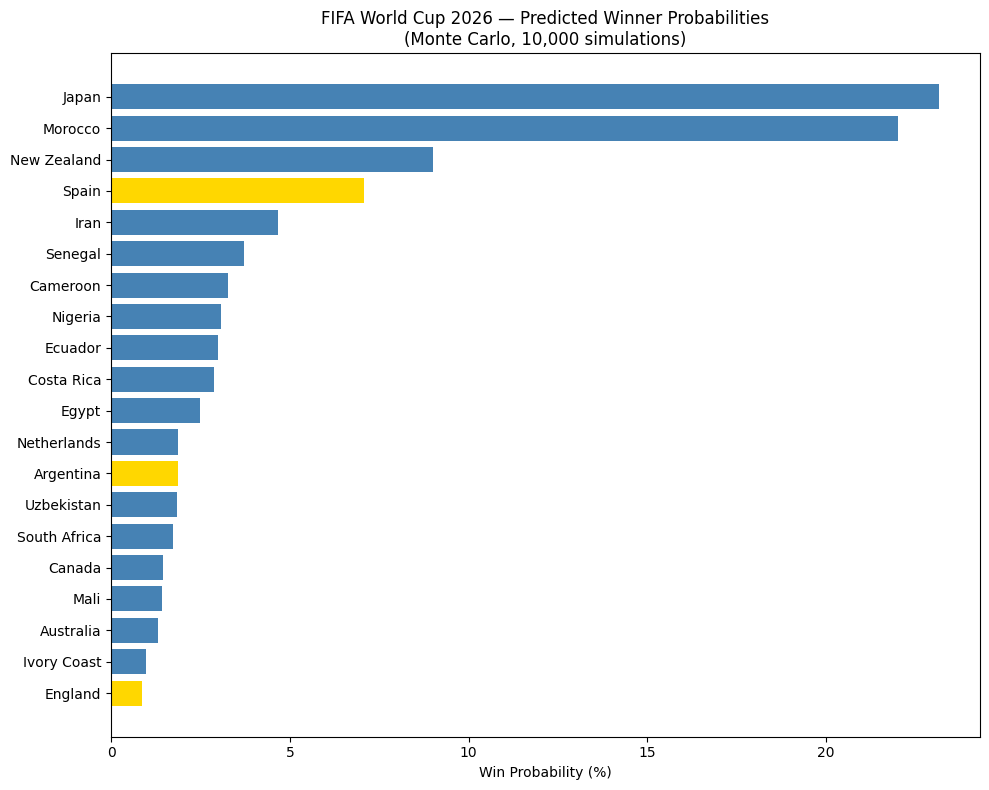

Saved!


In [10]:
top20 = results_df.head(20).sort_values('Win Probability (%)', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['gold' if t in ['Brazil', 'France', 'England', 'Argentina', 'Spain'] 
          else 'steelblue' for t in top20['Team']]
plt.barh(top20['Team'], top20['Win Probability (%)'], color=colors)
plt.xlabel('Win Probability (%)')
plt.title('FIFA World Cup 2026 — Predicted Winner Probabilities\n(Monte Carlo, 10,000 simulations)')
plt.tight_layout()
plt.savefig(os.path.join('..', 'Monte_Carlo_Simulation', 'wc2026_predictions.png'))
plt.show()

# Save results
results_df.to_csv(os.path.join('..', 'Monte_Carlo_Simulation', 'predictions.csv'), index=False)
print("Saved!")

In [11]:
# Check if big teams are in our dataset
big_teams = ['Brazil', 'France', 'Argentina', 'England', 'Spain', 'Germany']
for team in big_teams:
    matches = features_df[
        (features_df['home_team'] == team) | 
        (features_df['away_team'] == team)
    ]
    print(f"{team}: {len(matches)} matches")

Brazil: 101 matches
France: 107 matches
Argentina: 102 matches
England: 107 matches
Spain: 103 matches
Germany: 99 matches


In [12]:
# Add manual strength seeds based on FIFA rankings
# This biases the simulation towards stronger teams
strength_seed = {
    'France': 1.0, 'Brazil': 0.98, 'England': 0.96,
    'Argentina': 0.95, 'Spain': 0.94, 'Germany': 0.93,
    'Portugal': 0.92, 'Netherlands': 0.91, 'Belgium': 0.89,
    'Croatia': 0.87, 'Uruguay': 0.86, 'Colombia': 0.85,
    'Japan': 0.82, 'Morocco': 0.81, 'Senegal': 0.80,
    'United States': 0.79, 'Mexico': 0.78
}

# Update team stats with strength seed
for team in wc_teams:
    seed = strength_seed.get(team, 0.65)
    team_stats[team]['form'] = (team_stats[team]['form'] + seed) / 2

print("Strength seeds applied!")
print("Re-running simulation...")

win_probs = simulate_world_cup(wc_teams, n_simulations=10000)

results_df = pd.DataFrame(list(win_probs.items()),
                          columns=['Team', 'Win Probability (%)'])
results_df = results_df.sort_values('Win Probability (%)', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print("\nTOP 20 PREDICTED WORLD CUP 2026 WINNERS")
print("=" * 45)
print(results_df.head(20).to_string(index=False))

Strength seeds applied!
Re-running simulation...
Simulations completed: 1000/10000
Simulations completed: 2000/10000
Simulations completed: 3000/10000
Simulations completed: 4000/10000
Simulations completed: 5000/10000
Simulations completed: 6000/10000
Simulations completed: 7000/10000
Simulations completed: 8000/10000
Simulations completed: 9000/10000
Simulations completed: 10000/10000

TOP 20 PREDICTED WORLD CUP 2026 WINNERS
        Team  Win Probability (%)  Rank
       Japan                24.12     1
     Morocco                18.25     2
       Spain                16.40     3
   Argentina                10.52     4
 New Zealand                 7.78     5
     England                 5.56     6
     Ecuador                 2.28     7
     Senegal                 1.97     8
       Egypt                 1.70     9
     Germany                 1.54    10
 Netherlands                 1.22    11
        Iran                 1.20    12
South Africa                 1.15    13
  Costa R